# Real-world Data Wrangling
#### Steffany McWaters
With the help of:
* Udacity's Advanced Data Wrangling and Data Modeling
* Datetime Module Documentation https://docs.python.org/3/library/datetime.html
* Pytrends Documentation https://pypi.org/project/pytrends/
* pandas Timestamp Documentation https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Timestamp.html
* FBI Crime Data Explorer https://cde.ucr.cjis.gov/LATEST/webapp/#/pages/downloads
* Seaborn Regression Plot Documentation https://seaborn.pydata.org/generated/seaborn.regplot.html

## 1. Gather data

### **1.1.** Problem Statement
This project is motivated by the idea that pet ownership may support personal well-being and that homes with pets may be less attractive to potential burglars. Because direct daily pet-ownership data are unavailable, the analysis will examine whether Google search interest in common pet products, a limited proxy for pet-related activity, is  associated with reported burglary and breaking-and-entering offenses in North Carolina from 2021 through 2025.

The first dataset will contain daily Google Trends results collected with Pytrends for pet-product terms such as food, beds, kennels, treats, and collars. The second dataset consists of yearly FBI NIBRS CSV files merged and filtered for North Carolina property offenses.



### **1.2.** Gather at least two datasets using two different data gathering methods


#### Dataset 1

Type: Time-series data loaded into a pandas DataFrame and saved as a CSV file

Method: The data was gathered using the Gather data by accessing APIs method through Pytrends, an unofficial interface for Google Trends. I selected this dataset because it measures changes in North Carolina search interest for products commonly associated with pet ownership from 2021 through 2025.

Dataset variables:

*   date: Date associated with each daily Google Trends observation
*   kennel: Adjusted relative Google search interest for 'kennel' within the Pets & Animals category
*   food: Adjusted relative Google search interest for 'food' within the Pets & Animals category
*   bed: Adjusted relative Google search interest for 'bed' within the Pets & Animals category
*   treats: Adjusted relative Google search interest for 'treats' within the Pets & Animals category
*   collar: Adjusted relative Google search interest for 'collar' within the Pets & Animals category

In [137]:
import pandas as pd
from pytrends.request import TrendReq
from pathlib import Path

Access Google search trends using pytrends.

* Each raw Google Trends request returns relative interest scores from 0 - 100.
* Overlapping periods are rescaled to create one comparable 5-year index.

In [138]:
pytrends = TrendReq(hl='en-US', tz = 240) # Eastern time zone in the United States

In [118]:
# Terms used as a proxy for pet ownership
search_terms = ['kennel', 'food', 'bed', 'treats', 'collar']


In [140]:
# Create a function that automates the steps for retrieving trend data
def get_trends_period(start_date, end_date):
    start_text = pd.Timestamp(start_date).strftime('%Y-%m-%d')
    end_text = pd.Timestamp(end_date).strftime('%Y-%m-%d')

    pytrends.build_payload(
        search_terms,
        cat = 66,
        timeframe = f'{start_text} {end_text}',
        geo = 'US-NC',
        gprop = ''
    )

    period_data = pytrends.interest_over_time()

    period_data = period_data.drop(columns='isPartial', errors='ignore')

    return period_data

In [143]:
# Create a function that finds shared dates between periods, compares average scores on those dates, calculates a scale factor, scales the newest period, removes overlapping dates and stacks newest dates to the existing data
def scale_and_combine(existing_data, new_period):
    overlap_dates = existing_data.index.intersection(new_period.index)

    existing_overlap_average = (existing_data.loc[overlap_dates, search_terms].mean(axis=1))

    new_overlap_average = (new_period.loc[overlap_dates, search_terms].mean(axis=1))

    scale_factor = (existing_overlap_average.sum() / new_overlap_average.sum())

    new_period_scaled = new_period * scale_factor

    new_dates = new_period_scaled[new_period_scaled.index > existing_data.index.max()]

    combined_data = pd.concat([existing_data, new_dates])

    return combined_data

In [148]:
# Define start and end dates of product interest trends collection
project_start = pd.Timestamp('2021-01-01')
project_end = pd.Timestamp('2025-12-31')
# Request 89 days of data at a time
window_days = 89
# Overlap by 7 days, used to determine scale factor
overlap_days = 7


In [149]:
# Calculate the first window's start and end dates
current_start = project_start
current_end = min(current_start + pd.Timedelta(days=window_days - 1), project_end)
current_start, current_end

(Timestamp('2021-01-01 00:00:00'), Timestamp('2021-03-30 00:00:00'))

In [150]:
# Retrieve trend data for the first 89 days
daily_trends = get_trends_period(current_start, current_end)

In [152]:
import time

# Continue until the dataset reaches the final project date
while current_end < project_end:
    # Begin the next period 7 days before the current period ends
    next_start = current_end - pd.Timedelta(days=overlap_days - 1)

    # Calculate the end of the next 89 day period
    # min() prevents the date from exceeding project_end date
    next_end = min(next_start + pd.Timedelta(days=window_days - 1), project_end)

    # Get the next period from Google Trends
    new_period = get_trends_period(next_start, next_end)

    # Scale the new period and stack it
    daily_trends = scale_and_combine(daily_trends, new_period)

    # Show progress
    print(f'Added data through {next_end.date()}: {daily_trends.shape[0]} total rows')

    # Move the current ending date forward
    current_start = next_start
    current_end = next_end

    # Pause to avoid sending requests too quickly
    time.sleep(10)


Added data through 2021-06-20: 171 total rows
Added data through 2021-09-10: 253 total rows
Added data through 2021-12-01: 335 total rows
Added data through 2022-02-21: 417 total rows
Added data through 2022-05-14: 499 total rows
Added data through 2022-08-04: 581 total rows
Added data through 2022-10-25: 663 total rows
Added data through 2023-01-15: 745 total rows
Added data through 2023-04-07: 827 total rows
Added data through 2023-06-28: 909 total rows
Added data through 2023-09-18: 991 total rows
Added data through 2023-12-09: 1073 total rows
Added data through 2024-02-29: 1155 total rows
Added data through 2024-05-21: 1237 total rows
Added data through 2024-08-11: 1319 total rows
Added data through 2024-11-01: 1401 total rows
Added data through 2025-01-22: 1483 total rows
Added data through 2025-04-14: 1565 total rows
Added data through 2025-07-05: 1647 total rows
Added data through 2025-09-25: 1729 total rows
Added data through 2025-12-16: 1811 total rows
Added data through 2025-

In [153]:
# Confirm expected min and max dates, look for duplicate records and null entries
daily_trends.index.min(), daily_trends.index.max(), daily_trends.index.duplicated().sum(), daily_trends.isna().sum()

(Timestamp('2021-01-01 00:00:00'),
 Timestamp('2025-12-31 00:00:00'),
 np.int64(0),
 kennel    0
 food      0
 bed       0
 treats    0
 collar    0
 dtype: int64)

In [154]:
# Save the raw Google trends dataset for later use
daily_trends.to_csv('NC_pet_product_trends_2021_2025.csv')

#### **Dataset 2**

Type: Multiple CSV files combined into a pandas DataFrame

Method: The data was gathered using the Download Data Manually method from the FBI Crime Data Explorer at https://cde.ucr.cjis.gov/LATEST/webapp/#/pages/downloads. I selected this dataset because it contains detailed records that can be used to measure reported property offenses for the years 2021-2025.

Dataset variables:

*   incident_date: Date on which the reported incident occurred
*   offense_code: FBI code identifying the type of offense
*   offense_name: Readable name of the reported offense
*   offense_category_name: General category assigned to the offense
*   county_name: North Carolina county associated with the reporting agency
*   crime_against: Classification indicating whether the offense was against property, a person, or society

In [286]:
from zipfile import ZipFile
from pathlib import Path


In [70]:
# Create a function that reads and merges columns the FBI csv files needed for this investigation
# The FBI database provides a separate download for each year

def prepare_nibrs_year(folder_path):
    folder_path = Path(folder_path)

    incidents = pd.read_csv(folder_path / "NIBRS_incident.csv",
                            usecols = [
                                'data_year',
                                'nibrs_month_id',
                                'incident_id',
                                'agency_id',
                                'incident_date'
                            ])
    offenses = pd.read_csv(folder_path / "NIBRS_OFFENSE.csv",
                           usecols = [
                               'data_year',
                               'incident_id',
                               'offense_id',
                               'offense_code'
                           ])
    offense_types = pd.read_csv(folder_path / "NIBRS_OFFENSE_TYPE.csv",
                                usecols = [
                                    'offense_code',
                                    'offense_name',
                                    'crime_against',
                                    'offense_category_name'
                                ])
    agencies = pd.read_csv(folder_path / "agencies.csv",
                         usecols = [
                             'data_year',
                             'agency_id',
                             'state_postal_abbr',
                             'county_name'
                         ])
    # Combine offenses with incidents on keys data_year and incident_id
    # Note: one incident_id has the potential to appear in more than one yearly file, so incident_id and data_year together is more accurate for exploration
    combined_data = offenses.merge(incidents,
                                   on = ['data_year', 'incident_id'],
                                   how = 'inner', # keep offenses that have a matching incident
                                   validate = 'many_to_one') # one incident can have many offenses
    # Now combine with offense_types to add readable crime category
    combined_data = combined_data.merge(offense_types,
                                        on = 'offense_code',
                                        how = 'left', # keep all offense rows, even those without offense_codes
                                        validate = 'many_to_one') # many offenses with have the same offense_code, each with one definition
    # Now combine with agencies to add state and county
    combined_data = combined_data.merge(agencies,
                                        on = ['data_year', 'agency_id'],
                                        how = 'left', # keep all offense rows
                                        validate = 'many_to_one') # many offense rows from one agency
    # Filter the table to keep data from NC and property crimes
    # .copy() creates a DataFrame separate from the original combined_data
    combined_data = combined_data[
        (combined_data['state_postal_abbr'] == 'NC') &
        (combined_data['crime_against'] == 'Property')].copy()
    # Return the final dataset combined_data
    return combined_data

In [71]:
years = [2021, 2022, 2023, 2024, 2025] # years to be investigated
crime_by_year = {} # empty dictionary for storing yearly crime DataFrames

In [72]:
# Extract each yearly zip file
for yr in years:
    zip_path = Path(fr'C:\Users\steff\Downloads\NC-{yr}.zip')
    extract_folder = Path('NC_crime_data') / str(yr)

    with ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)

    print(f'Extracted {yr}') # Check for completion

Extracted 2021
Extracted 2022
Extracted 2023
Extracted 2024
Extracted 2025


In [73]:
# Find folders containing each year's CSV files
data_folders = {}

for yr in years:
    extract_folder = Path('NC_crime_data') / str(yr)

    incident_file = next(extract_folder.rglob('NIBRS_incident.csv'))

    data_folders[yr] = incident_file.parent # returns folder containing the incident file and saves in data_folders dictionary

    print(yr, data_folders[yr]) # Check for completion

2021 NC_crime_data\2021
2022 NC_crime_data\2022
2023 NC_crime_data\2023\NC
2024 NC_crime_data\2024
2025 NC_crime_data\2025


In [74]:
# Create a DataFrame for each year
for yr in years:
    crime_by_year[yr] = prepare_nibrs_year(data_folders[yr])
    print(yr, crime_by_year[yr].shape)

2021 (337746, 12)
2022 (345497, 12)
2023 (343890, 12)
2024 (331271, 12)
2025 (307154, 12)


In [75]:
# Concatenate the 5 separate DataFrames into one DataFrame
crime_data = pd.concat(crime_by_year.values(), ignore_index = True)
crime_data.shape

(1665558, 12)

In [76]:
# Confirm that each year still holds the expected number of records
crime_data['data_year'].value_counts().sort_index()

data_year
2021    337746
2022    345497
2023    343890
2024    331271
2025    307154
Name: count, dtype: int64

In [77]:
# Save the DataFrame to a csv to eliminate reprocessing
crime_data.to_csv('NC_property_crime_2021_2025.csv', index = False)

## 2. Assess data

### Quality Issue 1: Unexpected datatype

In [201]:
# Inspecting the dataframe visually using the .head() method
# Hover over column headings for data types
crime_data.head(20)

,data_year,offense_id,incident_id,offense_code,agency_id,nibrs_month_id,incident_date,offense_name,crime_against,offense_category_name,state_postal_abbr,county_name
0,2021,161647885,134219183,290,10873,19305428,2021-01-01,Destruction/Damage/Vandalism of Property,Property,Destruction/Damage/Vandalism of Property,NC,ALAMANCE
1,2021,161651682,134221667,290,10873,19305428,2021-01-01,Destruction/Damage/Vandalism of Property,Property,Destruction/Damage/Vandalism of Property,NC,ALAMANCE
2,2021,167234507,139020440,290,10873,19305428,2021-01-02,Destruction/Damage/Vandalism of Property,Property,Destruction/Damage/Vandalism of Property,NC,ALAMANCE
3,2021,161651685,134221670,26A,10873,19305428,2021-01-02,False Pretenses/Swindle/Confidence Game,Property,Fraud Offenses,NC,ALAMANCE
4,2021,161647887,134219185,220,10873,19305428,2021-01-03,Burglary/Breaking & Entering,Property,Burglary/Breaking & Entering,NC,ALAMANCE
5,2021,161647893,134219190,220,10873,19305428,2021-01-04,Burglary/Breaking & Entering,Property,Burglary/Breaking & Entering,NC,ALAMANCE
6,2021,161647896,134219191,290,10873,19305428,2021-01-05,Destruction/Damage/Vandalism of Property,Property,Destruction/Damage/Vandalism of Property,NC,ALAMANCE
7,2021,167422966,139184660,23H,10873,19305428,2021-01-05,All Other Larceny,Property,Larceny/Theft Offenses,NC,ALAMANCE
8,2021,167234511,139020444,26C,10873,19305428,2021-01-05,Impersonation,Property,Fraud Offenses,NC,ALAMANCE
9,2021,167234512,139020445,23H,10873,19305428,2021-01-06,All Other Larceny,Property,Larceny/Theft Offenses,NC,ALAMANCE


When hovering over the incident_date column heading in the output above, the variable is identified as a string data type. Although the values appear to be dates, they are not stored as datetime variables and will present analysis issues downline.

In [202]:
# Inspecting the dataframe programmatically
crime_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1665558 entries, 0 to 1665557
Data columns (total 12 columns):
 #   Column                 Non-Null Count    Dtype
---  ------                 --------------    -----
 0   data_year              1665558 non-null  int64
 1   offense_id             1665558 non-null  int64
 2   incident_id            1665558 non-null  int64
 3   offense_code           1665558 non-null  str  
 4   agency_id              1665558 non-null  int64
 5   nibrs_month_id         1665558 non-null  int64
 6   incident_date          1665558 non-null  str  
 7   offense_name           1665558 non-null  str  
 8   crime_against          1665558 non-null  str  
 9   offense_category_name  1665558 non-null  str  
 10  state_postal_abbr      1665558 non-null  str  
 11  county_name            1665558 non-null  str  
dtypes: int64(5), str(7)
memory usage: 152.5 MB


In [203]:
crime_data['incident_date'].dtype

<StringDtype(storage='python', na_value=nan)>

### Issue and justification:
Visual examination of the first 20 records of the crime_data DataFrame showed that while incident_date values appeared to be in date format, hovering over the column heading identified them as string values. I inspected the issue programmatically with crime_data.info() to review the datatypes and completeness of the DataFrame, and the used crime_data['incident_date'].dtype to specifically confirm that the column was stored as an object type rather than a datetime type. This is a quality issue because dates stored as strings cannot be reliably used for time-based grouping, comparison, or merging with the Google Trends data in the daily_trends DataFrame.

### Quality Issue 2: Range outside of rules expected for this data

In [204]:
# Use describe to examine the range and distribution of product search-interest variables
daily_trends.describe()

,kennel,food,bed,treats,collar
count,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000
mean,8.169812,75.155777,9.684056,7.925962,10.397234
std,4.886712,10.363347,4.713616,4.852536,4.626676
min,0.000000,38.964590,0.000000,0.000000,0.000000
25%,7.092382,67.755475,8.141157,6.532158,8.523504
50%,9.118777,74.184661,10.176446,8.967636,10.794377
75%,11.194091,81.733111,12.448614,11.000000,13.150545
max,24.910101,121.764344,27.674585,25.803328,25.906505


In [205]:
#FILL IN - Inspecting the dataframe visually
daily_trends.sort_values(by = 'food', ascending = False).head(40)

,kennel,food,bed,treats,collar
date,,,,,
2025-01-04,13.394078,121.764344,18.264652,14.611721,12.176434
2023-11-12,0.000000,110.698341,16.604751,11.069834,13.283801
2022-07-17,16.203071,108.020475,12.962457,9.721843,9.721843
2024-01-20,12.901664,107.513868,10.751387,11.826526,10.751387
2025-07-12,14.925177,106.608406,8.528672,0.000000,10.660841
2023-06-24,14.879571,106.282649,10.628265,12.753918,9.565438
2023-11-11,0.000000,106.270408,7.748884,9.962851,13.283801
2022-07-10,15.122867,105.860066,15.122867,9.721843,11.882252
2024-02-10,0.000000,105.363591,12.901664,8.601109,12.901664


### Issue and justification:
Google Trends reports relative product search interest on a scale from 0 to 100, where 100 represents the highest interest. Since Google provides at most 90 daily records at a time and normalizes each request separately, values from the different periods could not be compared directly without placing them on a common scale, which was done before adding each 89 day period to the collective dataset. While scaling the separate periods created a comparable five-year series, it also caused some adjusted food values to exceed 100, which was seen during programmatic assessment using daily_trends.describe(). That showed that the maximum value in the food column is approximately 121.76, exceeding the Google Trends scale. I then visually assessed this issue by sorting the daily_trends DataFrame in descending order by the food variable and displayed the first 40 records. The first 38 values were at or above 100, while records 39 and 40 in this sort were the first values below 100. These methods were appropriate because .describe() quickly identified the maximum value, while sorting and viewing the highest records sorted by the food values showed the extent of the issue and confirmed that it affected multiple observations rather than a single unexpected value. This is a quality issue because the completed variable no longer matches the documented range of the original measure, which could make the results misleading or difficult to interpret.

### Tidiness Issue 1: Datasets with different observational units

In [212]:
#Visually inspect the first 20 records in each dataset
print('The first 20 records of the crime_data DataFrame: \n', crime_data.head(20))
print('/n The first 20 records of the daily_trends DataFrame: /n', daily_trends.head(20))

The first 20 records of the crime_data DataFrame: 
     data_year  offense_id  incident_id offense_code  agency_id  \
0        2021   161647885    134219183          290      10873   
1        2021   161651682    134221667          290      10873   
2        2021   167234507    139020440          290      10873   
3        2021   161651685    134221670          26A      10873   
4        2021   161647887    134219185          220      10873   
5        2021   161647893    134219190          220      10873   
6        2021   161647896    134219191          290      10873   
7        2021   167422966    139184660          23H      10873   
8        2021   167234511    139020444          26C      10873   
9        2021   167234512    139020445          23H      10873   
10       2021   161647901    134219196          23H      10873   
11       2021   161647905    134219199          26B      10873   
12       2021   161651692    134221676          23H      10873   
13       2021   16723451

In [216]:
# Count the number of crime records and Google Trends records per date
crime_rows_per_day = crime_data.groupby('incident_date').size()
trend_rows_per_day = daily_trends.groupby('date').size()

print('Number of rows in the crime_data DataFrame per day, 2021-2025: \n', crime_rows_per_day.head())
print('Number of rows in the daily-trends DataFrame per day, 2021-2025: \n', trend_rows_per_day.head())

Number of rows in the crime_data DataFrame per day, 2021-2025: 
 incident_date
2021-01-01     984
2021-01-02     838
2021-01-03     768
2021-01-04    1055
2021-01-05    1027
dtype: int64
Number of rows in the daily-trends DataFrame per day, 2021-2025: 
 date
2021-01-01    1
2021-01-02    1
2021-01-03    1
2021-01-04    1
2021-01-05    1
dtype: int64


### Issue and justification:
Visual inspection with .head(20) showed that dates repeat within the FBI dataset, while each date only appears once in the Google Trends dataset. Programmatic assessment using .groupby().size() confirmed that the FBI dataset contains multiple offense records per date, while the Google Trends dataset contains only one record per date. Therefore, we see that the two datasets have different observational units and levels of granularity. The intended observational unit for the final analysis is one day in North Carolina. The fact that each row in the Google Trends dataset represents one day while each row in the FBI dataset represents one reported offense, causing the same date to appear in multiple rows, means the tidy-data requirement that each row represents one observation is violated. Therefore, the FBI burglary records must be groupd by date and counted so that each row represents one day containing that day's burglary count.

### Tidiness Issue 2: Observational unit of interest in more than one table

In [217]:
# Print the first 5 observations of both datasets
print('The first 5 observations of tne crime_data dataset: \n', crime_data.head())
print('The first 5 observations of the daily_trends dataset: \n', daily_trends.head())

The first 5 observations of tne crime_data dataset: 
    data_year  offense_id  incident_id offense_code  agency_id  nibrs_month_id  \
0       2021   161647885    134219183          290      10873        19305428   
1       2021   161651682    134221667          290      10873        19305428   
2       2021   167234507    139020440          290      10873        19305428   
3       2021   161651685    134221670          26A      10873        19305428   
4       2021   161647887    134219185          220      10873        19305428   

  incident_date                              offense_name crime_against  \
0    2021-01-01  Destruction/Damage/Vandalism of Property      Property   
1    2021-01-01  Destruction/Damage/Vandalism of Property      Property   
2    2021-01-02  Destruction/Damage/Vandalism of Property      Property   
3    2021-01-02   False Pretenses/Swindle/Confidence Game      Property   
4    2021-01-03              Burglary/Breaking & Entering      Property   

        

In [222]:
# Print the variables stored in each dataset
print('The variables in the crime_data dataset: \n', crime_data.columns)
print('The variables in the daily_trends dataset: \n', daily_trends.columns)

The variables in the crime_data dataset: 
 Index(['data_year', 'offense_id', 'incident_id', 'offense_code', 'agency_id',
       'nibrs_month_id', 'incident_date', 'offense_name', 'crime_against',
       'offense_category_name', 'state_postal_abbr', 'county_name'],
      dtype='str')
The variables in the daily_trends dataset: 
 Index(['kennel', 'food', 'bed', 'treats', 'collar'], dtype='object')


In [226]:
# Print the index name for the daily_trends dataset
print(f'The index for the daily_trends dataset is {daily_trends.index.name}.')

The index for the daily_trends dataset is date.


### Issue and justification:
The single observational unit of interest, one day in North Carolina, is represented across two tables, crime_data and daily_trends, violating the data-tidiness rule requiring that each type of observational unit forms one table. Their shared key is also arranged differently, with incident_date a column in the FBI dataset and date as the index in the daily_trends dataset.
I used the .head() method on both datasets for visual assessment because this method allowed me to compare how observations and variables were arranged in each table. This showed that crime variables and search-interest variables are stored separately, with dates displayed differently in each table. For the programmatic assessment, I used .columns to identify exactly which variables belonged to which datasset. The absence of date from the list of daily_trends columns indicated that it is not stored as a regular column. Therefore, I ran daily_trends.index.name to confirm that the Google Trends dates are stored in an index named date. Together, these methods confirmed that variables describing the same intended daily observation are divided between two tables and that their shared date key is not stored consistently.

## 3. Clean data

In [227]:
# Make copies of the datasets to ensure the raw dataframes
# are not impacted
daily_trends_copy = daily_trends.copy()
crime_data_copy = crime_data.copy()

### **Quality Issue 1: Improper data type**

In [232]:
# Change incident_date data type from str to datetime data type
crime_data_copy['incident_date'] = pd.to_datetime(crime_data_copy['incident_date'])

In [233]:
# What is the datatype of incident_date in the crime_data_copy dataset?
crime_data_copy['incident_date'].dtype

dtype('<M8[us]')

### Justification:
I converted incident_date from a string to a datetime datatype using pd.to_datetime(). This cleaning step was necessary because the values represent calendar dates and must be recognized as dates rather than text for further analysis. A datetime datatype allows the records to be grouped and counted by day and prepared the date variable to be matched with the Google Trends dates when the datasets are combined.

### **Quality Issue 2: Values outside of expected range**

In [234]:
#Normalize all 5 rescaled search-term columns
# search_terms holds the variable names of the rescaled data in daily_trends_copy

# Find the highest value across all search terms and dates
max_value = daily_trends_copy[search_terms].to_numpy().max()

# Normalize all search values using the same scaling factor
daily_trends_copy[search_terms] = (daily_trends_copy[search_terms] / max_value * 100)

In [235]:
# Confirm that no search_term interest values exceeds 100
daily_trends_copy[search_terms].max()

kennel     20.457632
food      100.000000
bed        22.727988
treats     21.191202
collar     21.275937
dtype: float64

### Justification:
I normalized all five rescaled Google Trends variables using the highest value found across all search terms and dates as the common scaling factor. This method returns the completed dataset to a consistent 0-100 range while preserving proportional relationships among the search terms for the dates within the dataset. I used one factor across the entire dataset instead of normalizing each column separately because separate normalization would give every search term its own maximum of 100 and would distort comparisons between the terms.

### **Tidiness Issue 1: Datasets with different observational units of interest

In [236]:
#Keep only burglary/breaking-and-entering offense reports (offense_code 220) in a new DataFrame
burglaries = crime_data_copy[crime_data_copy['offense_code'] == '220'].copy()

# Count the number of burglary records by date
# return incident_date from an index column to a regular column
daily_burglary_count = (burglaries.groupby('incident_date').size().reset_index(name = 'burglary_count'))

In [238]:
# Examine daily_burglary_count for expected count per day result
daily_burglary_count.head(), daily_burglary_count.tail()

(  incident_date  burglary_count
 0    2021-01-01             115
 1    2021-01-02              94
 2    2021-01-03             108
 3    2021-01-04             114
 4    2021-01-05             112,
      incident_date  burglary_count
 1821    2025-12-27              64
 1822    2025-12-28              59
 1823    2025-12-29              73
 1824    2025-12-30              66
 1825    2025-12-31              69)

In [247]:
# Verify that both datasets have the same number of observations
daily_burglary_count.shape, daily_trends_copy.shape

((1826, 2), (1826, 6))

In [241]:
# Confirm that each date in daily_burglary_count appears exactly once
daily_burglary_count['incident_date'].is_unique

True

In [243]:
# Date is still index in the Trends dataset
# Confirm that each date in daily_trends_copy appears exactly once
daily_trends_copy.index.is_unique

True

### Justification:
I filtered the FBI dataset to keep only records with offense code 220, which represents burglary/breaking and entering, because burglary is the crime examined in the research question. I then used .groupby('incident_date').size() to count the number of offense records for each date. Finally, I used reset_index(name = 'burglary_count') to return the date to a regular column and name the calculated count. This changed the FBI dataset from one row per reported offense to one row per day, giving it the same observational unit and level of granularity as the daily Google Trends dataset. I confirmed that each dataset, daily_burglary_count and daily_trends_data, has each date exactly once using .is_unique, noting that each dataset has 1826 records using .shape.

### **Tidiness Issue 2: Each type of observational unit should be in one table**

In [244]:
# Move the Google Trends date index into a regular column
daily_trends_copy = daily_trends_copy.reset_index()

In [245]:
# Rename incident_date to date so keys share the same name
daily_burglary_count = daily_burglary_count.rename(columns = {'incident_date': 'date'})

In [246]:
# verify that the steps above worked as expected
daily_trends_copy.head(), daily_burglary_count.head()

(        date     kennel       food        bed     treats     collar
 0 2021-01-01   7.391326  64.058162  12.318877   8.212585   6.570068
 1 2021-01-02   7.391326  65.700679  13.961394   9.855102   0.000000
 2 2021-01-03  11.497619  73.913263  13.961394  13.961394  13.961394
 3 2021-01-04   9.855102  55.024318   9.855102   7.391326   7.391326
 4 2021-01-05   0.000000  55.845577   7.391326   7.391326  12.318877,
         date  burglary_count
 0 2021-01-01             115
 1 2021-01-02              94
 2 2021-01-03             108
 3 2021-01-04             114
 4 2021-01-05             112)

In [250]:
# Confirm that the date columns have the same datatype
print(f'The datatype of date in daily_trends_copy is {daily_trends_copy['date'].dtype}.')
print(f'The datatype of date in daily_burglary_count is {daily_burglary_count['date'].dtype}.')

The datatype of date in daily_trends_copy is datetime64[s].
The datatype of date in daily_burglary_count is datetime64[us].


In [251]:
# Compare date ranges in the two datasets
print(f'daily_trends_copy date range is from {daily_trends_copy['date'].min()} to {daily_trends_copy['date'].max()}.')
print(f'daily_burglary_cout date range is from {daily_burglary_count['date'].min()} to {daily_burglary_count['date'].max()}.')

daily_trends_copy date range is from 2021-01-01 00:00:00 to 2025-12-31 00:00:00.
daily_burglary_cout date range is from 2021-01-01 00:00:00 to 2025-12-31 00:00:00.


In [252]:
# Combine the daily search-interest and burglary-count dataset on date
combined_data = daily_trends_copy.merge(daily_burglary_count, on = 'date', how = 'inner', validate = 'one_to_one')


In [254]:
# Validate that the merge worked as expected
print(combined_data.shape)
combined_data.head(), combined_data.tail()

(1826, 7)


(        date     kennel       food        bed     treats     collar  \
 0 2021-01-01   7.391326  64.058162  12.318877   8.212585   6.570068   
 1 2021-01-02   7.391326  65.700679  13.961394   9.855102   0.000000   
 2 2021-01-03  11.497619  73.913263  13.961394  13.961394  13.961394   
 3 2021-01-04   9.855102  55.024318   9.855102   7.391326   7.391326   
 4 2021-01-05   0.000000  55.845577   7.391326   7.391326  12.318877   
 
    burglary_count  
 0             115  
 1              94  
 2             108  
 3             114  
 4             112  ,
            date     kennel       food       bed    treats     collar  \
 1821 2025-12-27   9.107866  71.344948  9.866854  9.866854   0.000000   
 1822 2025-12-28   0.000000  70.585959  7.589888  9.107866  13.661799   
 1823 2025-12-29  11.384832  72.862925  9.107866  8.348877  12.902810   
 1824 2025-12-30   0.000000  69.826970  7.589888  0.000000   7.589888   
 1825 2025-12-31   0.000000  75.898881  9.107866  0.000000  11.384832   
 

### Justification:
I used reset_index() to change the Google Trends date index into a regular column and renamed the FBI incident_date column to date so both datasets have a consistently named key on which to merge. Before combining the two datasets, I verified that both datasets contained 1,826 unique daily observations and covered the same date range. I then used an inner merge on date because only dates present in both datasets should be included in the analysis. The validate = 'one_to_one' argument confirmed that each date matched no more than one row in either dataset. This created one tidy table in which each row represents one day in North Carolina and contains both the daily pet-product search interest values and the reported burglary-offense count.

In [256]:
# Create an overall pet-product search-interest measure
combined_data['pet_product_interest'] = (combined_data[search_terms].mean(axis = 1))

## 4. Update your data store

In [257]:
#Create folders for raw and cleaned data
data_folder = Path('data')
results_folder = Path('results')

data_folder.mkdir(exist_ok = True)
results_folder.mkdir(exist_ok = True)

# Save the raw FBI dataset
crime_data.to_csv(data_folder / 'NC_property_crime_2021_2025_raw.csv', index = False, encoding = 'utf-8')

# Save the raw Google Trends dataset without losing its date index
daily_trends.rename_axis('date').reset_index().to_csv(data_folder / 'NC_pet_product_trends_2021_2025_raw.csv', index = False, encoding = 'utf-8')

# Save a readable CSV version of the cleaned dataset for analysis
combined_data.to_csv(results_folder / 'NC_pet_trends_and_burglary_daily_2021_2025_cleaned.csv', index = False, encoding = 'utf-8')

# Save a pickle version to preserve dataypes
combined_data.to_pickle(results_folder / 'NC_pet_product_trends_2021_2025_cleaned.pkl')

## 5. Answer the research question

### **5.1:** Define and answer the research question

### Research question:
Is Google search interest in common pet products associated with reported burglary and breaking-and-entering offenses in North Carolina?

In [260]:
# Create a month variable from daily dates
combined_data['month'] = combined_data['date'].dt.to_period('M')

# Create one observation per month
monthly_data = (combined_data.groupby('month', as_index = False).agg(
    # Average the daily search-interest scores per month
    pet_product_interest = ('pet_product_interest', 'mean'),
    burglary_count = ('burglary_count', 'sum')
))

In [262]:
# Convert month variable from period datatype to datetime
monthly_data['month'] = monthly_data['month'].dt.to_timestamp()

In [263]:
# Print the first 5 records in monthly_data
monthly_data.head()

,month,pet_product_interest,burglary_count
0,2021-01-01,18.666411,3078
1,2021-02-01,17.973828,2906
2,2021-03-01,17.388038,2872
3,2021-04-01,17.279809,2650
4,2021-05-01,17.693202,3146


In [264]:
# Examine the shape of monthly_data
monthly_data.shape

(60, 3)

60 months over 3 variables

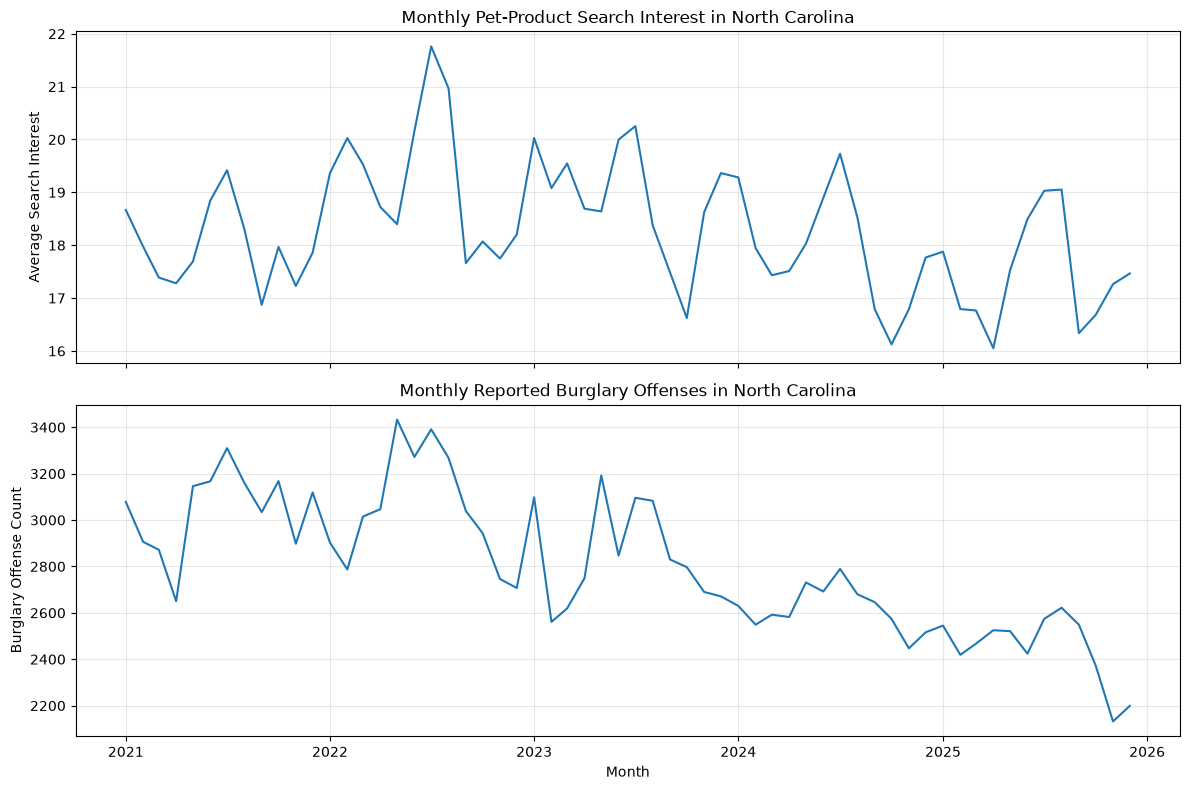

In [269]:
# Compare pet_product_interest and burglary_count over time
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows = 2,
    ncols = 1,
    figsize = (12, 8),
    sharex = True
)

# Plot monthly average pet-product search interest
axes[0].plot(
    monthly_data['month'],
    monthly_data['pet_product_interest']
)
axes[0].set_title('Monthly Pet-Product Search Interest in North Carolina')
axes[0].set_ylabel('Average Search Interest')
axes[0].grid(alpha = 0.3)

# Plot monthly reported burglary offenses
axes[1].plot(
    monthly_data['month'],
    monthly_data['burglary_count']
)
axes[1].set_title('Monthly Reported Burglary Offenses in North Carolina')
axes[1].set_ylabel('Burglary Offense Count')
axes[1].grid(alpha = 0.3)
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()

Both monthly pet-product search interest for the search term products and reported burglary offenses generally decreased in North Carolina from 2021 through 2025. Some peaks and declines occurred during similar periods, suggesting a possible positive association between the two measures. However, the shared long-term downward trend is not enough to determine whether monthly increases in search interest are consistently associated with monthly increases in burlgary.

In [270]:
# Compare month-to-month changes
# Calculate the change from the previous month for each variable
monthly_data['pet_interest_change'] = (monthly_data['pet_product_interest'].diff())
monthly_data['burglary_change'] = (monthly_data['burglary_count'].diff())

# Remove the first row because it has no previous month for comparison
monthly_changes = monthly_data.dropna(subset = ['pet_interest_change', 'burglary_change'])

In [271]:
# Measure the strength and direction of the relationship
change_correlation = monthly_changes[['pet_interest_change', 'burglary_change']].corr().iloc[0, 1]
change_correlation

np.float64(0.22256093831362683)

The correlation coefficient is approximately 0.223, indicating a weak positive relationship. Months with increasing pet-product search interest were somewhat more likely to also have increasing burglary counts, but the relationship was not strong or consistent.

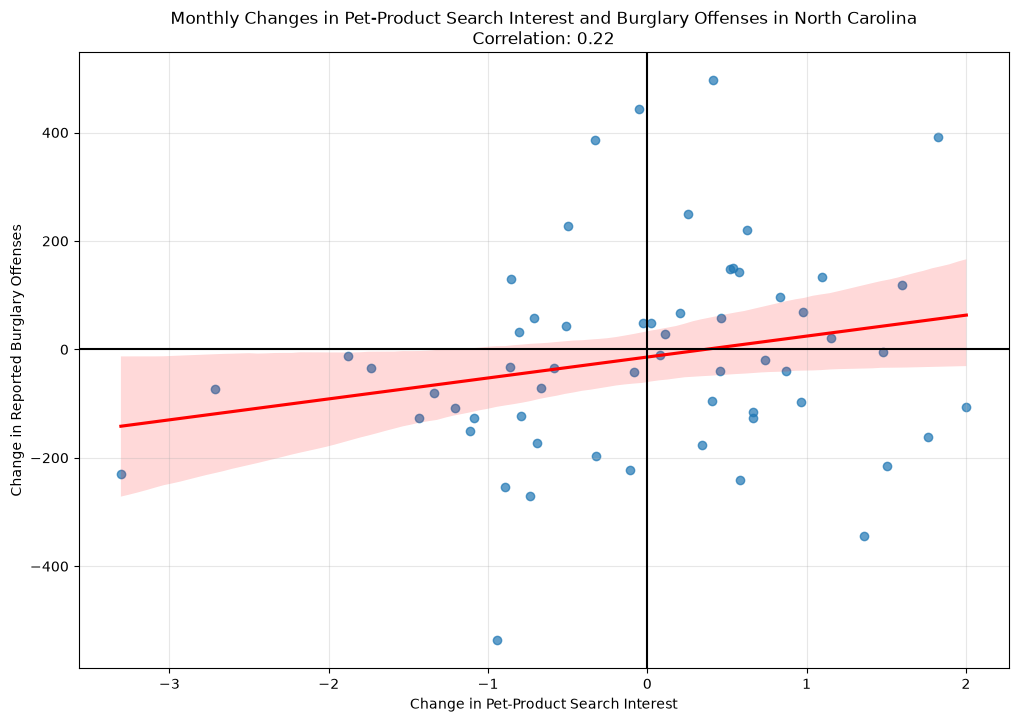

In [285]:
import seaborn as sns

# Plot month-to-month changes in pet product interest against month-to-month changes in burglary counts.
plt.figure(figsize = (12, 8))
# Regression line with default 95% confidence interval
sns.regplot(
    data = monthly_changes,
    x = 'pet_interest_change',
    y = 'burglary_change',
    scatter_kws = {'alpha': 0.7},
    line_kws = {'color': 'red'}
)

# Add horizontal and vertical axes at x = 0, y = 0
plt.axhline(0, color = 'black')
plt.axvline(0, color = 'black')

plt.title('Monthly Changes in Pet-Product Search Interest and Burglary Offenses in North Carolina\n' f'Correlation: {change_correlation:.2f}')
plt.xlabel('Change in Pet-Product Search Interest')
plt.ylabel('Change in Reported Burglary Offenses')
plt.grid(alpha = 0.3)

plt.show()

The scatterplot shows a weak positive relationship between monthly changes in pet-product search interest and monthly changes in reported burglary offenses. The correlation coefficient was approximately 0.223, meaning that increases in search interest were somewhat more likely to occur alongside increases in burglary counts, but the relationship was not strong or consistent. The wide scattering of points and confidence interval show substantial uncertainty, so the results do not demonstrate that pet-product interest causes changes in burglary.



### Conclusion
From 2021 through 2025, pet-product search interest and reported burglary offenses both generally declined in North Carolina. Month-to-month changes had a weak positive correlation of 0.223, providing limited evidence of an association but not supporting the expected inverse relationship. Google search interest is only a proxy for pet-related activity, so the analysis cannot determine whether pet ownership prevents or contributes to crime.

### Limitations
This analysis has several limitations. Google Trends search interest is only a proxy for pet ownership and does not directly measure it, while the selected search terms may not represent every type of owner. The Trends values were also collected in separate periods and rescaled, and the FBI dadta only reported burglary offenses from reporting agencies, so changes in reporting may have affected the counts. Finally, the statewide monthly analysis does not account for other factors that may influence burglary, and the weak correlation identifies an association rather than a causal relationship.

### **5.2:** Reflection


If I had more time, I would wait until the adoption dataset from The National Database Shelter Animals Count (https://www.shelteranimalscount.org/request-the-data) becomes available in 2027 and use adoption counts as a more direct measure of new pet ownership. Otherwise, continuing to use Google Trends, I would test additional or different search terms, because my choice of terms may have affected the quality and accuracy of the pet-ownership proxy. I would also investigate whether changes in FBI agency reporting affected the burglary counts across years. Finally, I would explore whether changes in pet-related activity are associated with crime in later months rather than only during the same month.